In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

df = pd.read_csv('resilience_dataset_final.csv')

categorical_cols = [
    'land_surface_condition',
    'foundation_type',
    'roof_type',
    'ground_floor_type',
    'other_floor_type',
    'position',
    'plan_configuration'
]

print('Features the model will train on:', list(df.columns))


Features the model will train on: ['count_floors_pre_eq', 'age_building', 'plinth_area_sq_ft', 'height_ft_pre_eq', 'land_surface_condition', 'foundation_type', 'roof_type', 'ground_floor_type', 'other_floor_type', 'position', 'plan_configuration', 'has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone', 'has_superstructure_stone_flag', 'has_superstructure_cement_mortar_stone', 'has_superstructure_mud_mortar_brick', 'has_superstructure_cement_mortar_brick', 'has_superstructure_timber', 'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered', 'has_superstructure_rc_engineered', 'has_superstructure_other', 'resilience_score']


In [2]:
# Add engineered features that capture structural and material resilience

df['slenderness_ratio'] = df['height_ft_pre_eq'] / (np.sqrt(df['plinth_area_sq_ft']) + 1e-5)
df['floor_load_intensity'] = df['plinth_area_sq_ft'] / (df['count_floors_pre_eq'] + 1e-5)
df['floor_height'] = df['height_ft_pre_eq'] / (df['count_floors_pre_eq'] + 1e-5)
df['volumetric_index'] = df['plinth_area_sq_ft'] * df['height_ft_pre_eq']
df['age_per_floor'] = df['age_building'] / (df['count_floors_pre_eq'] + 1e-5)

df['is_highly_vulnerable_material'] = (
    ((df['has_superstructure_mud_mortar_stone'] == 1) |
     (df['has_superstructure_mud_mortar_brick'] == 1)).astype(int)
)

df['is_engineered_material'] = (
    ((df['has_superstructure_rc_engineered'] == 1) |
     (df['has_superstructure_cement_mortar_brick'] == 1)).astype(int)
)

df['structural_age_stress'] = df['age_building'] * df['count_floors_pre_eq']
df['age_x_mud_mortar'] = df['age_building'] * df['is_highly_vulnerable_material']
df['slenderness_x_load'] = df['slenderness_ratio'] * df['floor_load_intensity']
df['engineered_x_age_stress'] = df['is_engineered_material'] * df['structural_age_stress']

df['plan_aspect_ratio'] = np.abs(df['plinth_area_sq_ft'] - (df['height_ft_pre_eq'] ** 2))
df['extreme_vulnerability_index'] = df['slenderness_ratio'] * df['is_highly_vulnerable_material'] * df['age_building']

print('Added engineered features; new column count:', len(df.columns))


Added engineered features; new column count: 36


In [9]:
# Prepare training data
X = df.drop(columns=['resilience_score'])
y = df['resilience_score']

# One-hot encode categorical variables
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

sample_weights = np.where((y_train < 25) | (y_train > 85), 4.0, 1.0)

regressor = xgb.XGBRegressor(
    max_depth=7,
    learning_rate=0.025,
    n_estimators=2000,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1,
    subsample=0.85,
    colsample_bytree=0.82,
    colsample_bylevel=0.8,
    reg_alpha=0.8,
    reg_lambda=1.8,
    min_child_weight=1,
    gamma=1.0,
    tree_method='hist',
    early_stopping_rounds=60,
    eval_metric='rmse',
)

regressor.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False,
    sample_weight=sample_weights,
)

print(f'Training complete. Best iteration: {regressor.best_iteration}')
print(f'Feature matrix shape: {X.shape}')


Training complete. Best iteration: 81
Feature matrix shape: (759998, 55)


In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = regressor.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=== MODEL TEST RESULTS ===")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared Score (R2): {r2:.4f}")

=== MODEL TEST RESULTS ===
Mean Absolute Error (MAE): 13.91
Root Mean Squared Error (RMSE): 17.36
R-squared Score (R2): 0.3392


In [5]:
print("Best iteration:")
print("predicted:",y_pred[1799])
print("actual:",y_test.iloc[1799])

Best iteration:
predicted: 40.964893
actual: 35.004246205993724


--- TOP 10 WORST PREDICTIONS ---
        Actual_Resilience  Predicted_Resilience  Absolute_Error
759360           0.000000             78.720108       78.720108
711388           5.456685             82.638977       77.182292
759482           2.561538             77.215317       74.653779
713737          10.287348             80.938255       70.650907
747054           9.929136             80.226318       70.297182
747272           9.929136             79.862495       69.933359
757956          14.560151             84.446396       69.886245
714710          12.575113             82.172501       69.597388
757933          14.560151             83.855347       69.295196
205131          95.803519             28.458923       67.344595


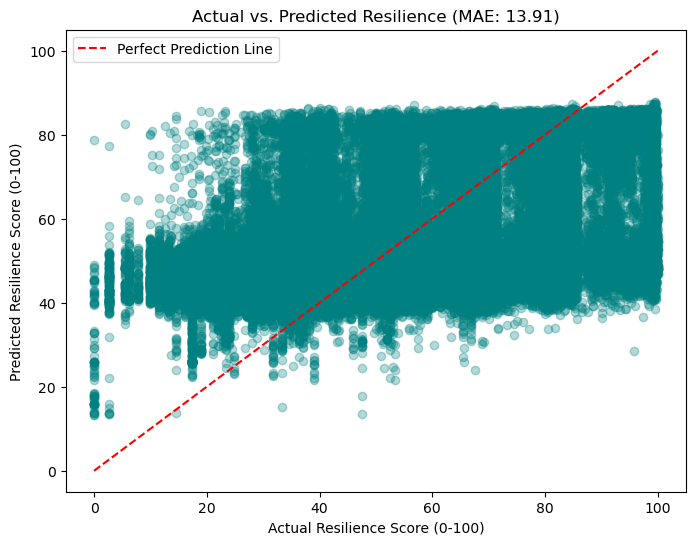

In [6]:
# Create an inspection DataFrame
df_inspect = pd.DataFrame({
    'Actual_Resilience': y_test,
    'Predicted_Resilience': y_pred,
    'Absolute_Error': np.abs(y_test - y_pred)
})

# Look at your 10 worst predictions to identify edge cases
print("--- TOP 10 WORST PREDICTIONS ---")
print(df_inspect.sort_values(by='Absolute_Error', ascending=False).head(10))

plt.figure(figsize=(8, 6))
plt.scatter(df_inspect['Actual_Resilience'], df_inspect['Predicted_Resilience'], alpha=0.3, color='teal')
plt.plot([0, 100], [0, 100], color='red', linestyle='--', label='Perfect Prediction Line')
plt.xlabel('Actual Resilience Score (0-100)')
plt.ylabel('Predicted Resilience Score (0-100)')
plt.title(f'Actual vs. Predicted Resilience (MAE: {mae:.2f})')
plt.legend()
plt.show()

In [7]:
# inspect anomalies
anomaly_check = df.loc[[711388, 714710, 757956, 759360]]
print(anomaly_check)

        count_floors_pre_eq  age_building  plinth_area_sq_ft  \
711388                    1             5                117   
714710                    1             5                303   
757956                    1             1                540   
759360                    1             5                147   

        height_ft_pre_eq land_surface_condition         foundation_type  \
711388                 8                   Flat           Bamboo/Timber   
714710                 9                   Flat           Bamboo/Timber   
757956                 8                   Flat                      RC   
759360                12                   Flat  Mud mortar-Stone/Brick   

                       roof_type ground_floor_type other_floor_type  \
711388  Bamboo/Timber-Heavy roof               Mud   Not applicable   
714710  Bamboo/Timber-Light roof               Mud   Not applicable   
757956  Bamboo/Timber-Light roof                RC   Not applicable   
759360  Bamboo/Timb

                                   Feature  Importance
20           is_highly_vulnerable_material    0.299365
5      has_superstructure_mud_mortar_stone    0.228502
27             extreme_vulnerability_index    0.112239
23                        age_x_mud_mortar    0.094999
6            has_superstructure_stone_flag    0.065878
31  foundation_type_Mud mortar-Stone/Brick    0.037502
11               has_superstructure_bamboo    0.021218
30      foundation_type_Cement-Stone/Brick    0.017146
45                   position_Not attached    0.010289
21                  is_engineered_material    0.009832


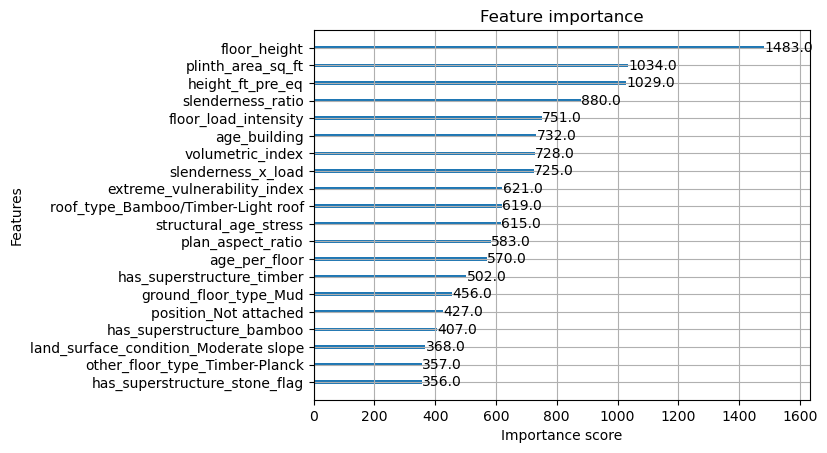

In [8]:
# Create a DataFrame of features and their importance
from xgboost import plot_importance


feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': regressor.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Get top 10 most important features
top_10_features = feature_importances.head(10)
print(top_10_features)

# Plot top 10 features
plot_importance(regressor, max_num_features=20)
plt.show()